# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import polars as pl
import pyarrow as pa
import dask.dataframe as dd
import altair as alt

import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text as sk_text
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import glob
import json
from pathlib import Path

import calendar
import geopandas as gpd
from geodatasets import get_path
from shapely.geometry import Point
import branca.colormap as cm

import folium
from folium.plugins import MarkerCluster
import folium
from folium.plugins import MarkerCluster
from folium.elements import MacroElement
from jinja2 import Template

DATA_PATH = Path("../data/UpdatedData/citibike_2023_combined.parquet/")
OUTPUT_PATH = Path("../output/")

# 2. Data Load & Process

Processing script should be in `preprocessing.ipynb`.

In [28]:
df = (
    pl.read_parquet(f"{DATA_PATH}/*.parquet")
    # 1) Parse to datetime and rename in one go
    .with_columns(
        pl.col("started_at").str.to_datetime().alias("start_time"),
        pl.col("ended_at").str.to_datetime().alias("end_time"),
    )
    # 2) Compute ride_time_seconds = end_time - start_time (in seconds)
    .with_columns(
        (pl.col("end_time") - pl.col("start_time"))
        .dt.total_seconds()
        .alias("ride_time_seconds")
    )
    # 3) Order by start_time
    .sort("start_time")
    # 4) Select columns in the exact order you want
    .select(
        "ride_id",
        "rideable_type",
        "start_time",
        "end_time",
        "ride_time_seconds",   # ← right after end_time
        "start_station_name",
        "start_station_id",
        "end_station_name",
        "end_station_id",
        "start_lat",
        "start_lng",
        "end_lat",
        "end_lng",
        "member_casual",
    )
)

# remove any start or end_station_name = null
df = df.filter(pl.col("end_station_name").is_not_null())
df= df.filter(pl.col("end_station_id").is_not_null())
df = df.filter(pl.col("start_station_name").is_not_null())
df= df.filter(pl.col("start_station_id").is_not_null())

# filter data out for ride_time < 2 hours or way too short ones like 1 minute
df = df.filter(pl.col("ride_time_seconds") < 2 * 3600)   
df = df.filter(pl.col("ride_time_seconds") >= 60)

df = df.filter(pl.col("start_time").dt.year() == 2023)
df = df.with_columns([
    pl.col("start_time").dt.month().alias("month"),
])

# filter data out for ride time that is negative or zero (not possible)
df = df.filter(pl.col("ride_time_seconds") > 0)

# Remove rides with identical start/end stations (probably some error)
df = df.filter(
    ~(
        (pl.col("start_station_id") == pl.col("end_station_id"))
    )
)

df = df.filter(
    ~(
        (pl.col("start_lat") == pl.col("end_lat"))
        & (pl.col("start_lng") == pl.col("end_lng"))
    )
)

df_map = df.to_pandas()

# 3. Visualization

### 3.1. NYC Bike Share Text Analysis: What Words Are Most Associated With City Bike Usage?

#### 3.1.1  Data Preparation

In [29]:
# pull all station names from both start and end columns
all_names_raw = (
    pl.concat([
        df.select(pl.col("start_station_name").alias("name")),
        df.select(pl.col("end_station_name").alias("name")),
    ])
    .drop_nulls("name")
    .unique()
)
station_list = all_names_raw["name"].to_list()

def clean_name(text: str) -> str:    # quick cleaner for station names
    text = text.lower()
    # remove punctuation and tidy spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)    
    text = re.sub(r"\s+", " ", text).strip()     
    return text  

cleaned_names = [clean_name(n) for n in station_list]

# words we want to remove so results stay meaningful
extra_stops = {
    "station", "street", "st", "st.", "ave", "avenue",
    "blvd", "road", "rd", "plaza", "pl", "sq",
    "north", "south", "east", "west", "n", "s", "e", "w",
    "citi", "bike", "bikes", "citibike", "citibikenyc",
    "new", "york", "nyc",
}

# merge default english stopwords with our custom list
all_stops = list(sk_text.ENGLISH_STOP_WORDS.union(extra_stops))

# turn station names into single words + two-word phrases
vec = CountVectorizer(
    stop_words=all_stops,
    ngram_range=(1, 2),      
    min_df=2                 
)

matrix = vec.fit_transform(cleaned_names)
ngram_terms = vec.get_feature_names_out()
ngram_counts = matrix.sum(axis=0).A1

# the terms sorted by how often they appear
ngram_table = (
    pd.DataFrame({"term": ngram_terms, "count": ngram_counts})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
print("Top 10 location words:")
print(ngram_table.head(10))

Top 10 location words:
         term  count
0        park    101
1    broadway     96
2       grand     45
3          10     40
4          31     38
5          dr     38
6  washington     37
7     madison     36
8        pkwy     32
9          34     30


#### 3.1.2 Word Cloud of Station Names

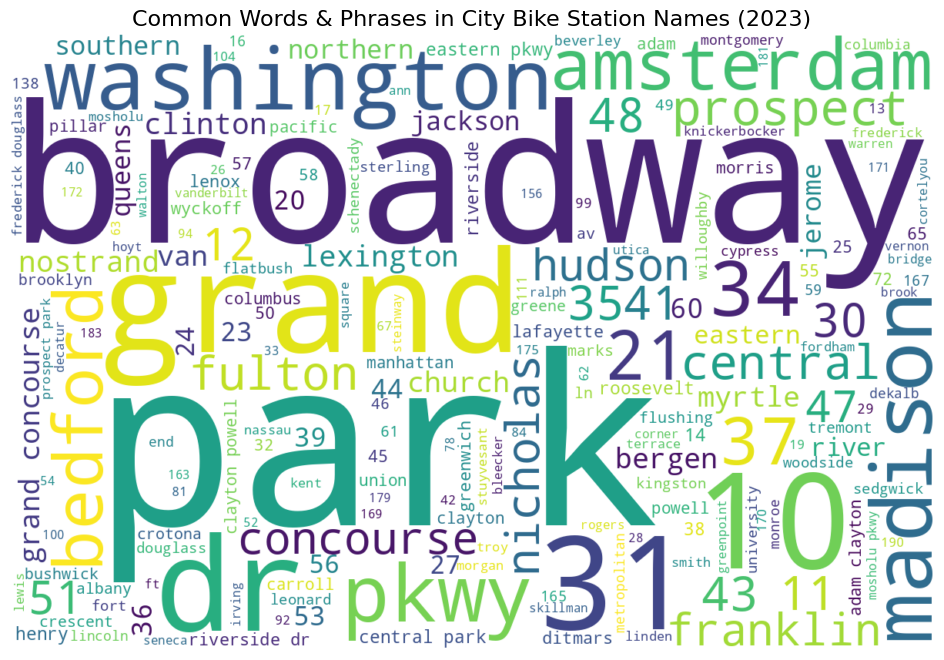

In [30]:
# using the top terms to keep the cloud readable
top_n = 200
freq_map = dict(
    zip(
        ngram_table.loc[: top_n - 1, "term"],
        ngram_table.loc[: top_n - 1, "count"],
    )
)

# the word cloud
wc = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    max_words=200,
    collocations=False
).generate_from_frequencies(freq_map)
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words & Phrases in City Bike Station Names (2023)", fontsize=16)
plt.show()

The word cloud highlights the most common location-based terms found in station names, with big standouts like park, broadway, and washington appearing across many sites. Numbers such as 10, 31, or 34 also show up because they come directly from station names (e.g., 10th Ave, 31st St), reflecting how closely the bike network mirrors real NYC streets and landmarks.

#### 3.1.3 

In [31]:
top_k = 25
top_terms = ngram_table.head(top_k)
(
    alt.Chart(top_terms)
    .mark_bar()
    .encode(
        x=alt.X("count:Q", title="Number of words"),
        y=alt.Y("term:N", sort="-x", title="Word / Phrase"),
        tooltip=["term", "count"],
    )
    .properties(
        title="Top Station-Related Words & Phrases",
        width=600,
        height=400,
    )
)

alt.Chart(...)

### 3.3 FACET - Ankit

When during the year do New Yorkers use Citi Bikes the most, and how does this vary across user groups?

In [41]:
ddf = dd.read_parquet(f"{DATA_PATH}/*.parquet")

#Parse datetimes
ddf["start_time"] = dd.to_datetime(ddf["started_at"])
ddf["end_time"]   = dd.to_datetime(ddf["ended_at"])

#ride_time_seconds
ddf["ride_time_seconds"] = (ddf["end_time"] - ddf["start_time"]).dt.total_seconds()

#Filter out null station names/ids
ddf = ddf[
    ddf["end_station_name"].notnull()
    & ddf["end_station_id"].notnull()
    & ddf["start_station_name"].notnull()
    & ddf["start_station_id"].notnull()
]

#Filter ride_time between 1 minute and 2 hours
ddf = ddf[(ddf["ride_time_seconds"] < 2 * 3600) & (ddf["ride_time_seconds"] >= 60)]

ddf = ddf[ddf["start_time"].dt.year == 2023]
ddf["month"] = ddf["start_time"].dt.month

#Remove negative or zero durations
ddf = ddf[ddf["ride_time_seconds"] > 0]

#Remove rides with identical start/end stations
ddf = ddf[ddf["start_station_id"] != ddf["end_station_id"]]
ddf = ddf[
    ~(
        (ddf["start_lat"] == ddf["end_lat"])
        & (ddf["start_lng"] == ddf["end_lng"])
    )
]

#Select columns and sort only when materializing (optional)
cols = [
    "ride_id",
    "rideable_type",
    "start_time",
    "end_time",
    "ride_time_seconds",
    "start_station_name",
    "start_station_id",
    "end_station_name",
    "end_station_id",
    "start_lat",
    "start_lng",
    "end_lat",
    "end_lng",
    "member_casual",
    "month",
]
ddf = ddf[cols]

In [45]:
ddf["hour"] = ddf["start_time"].dt.hour

agg = (
    ddf.groupby(["month_name", "hour", "member_casual"])
       .size()
       .compute()
       .reset_index(name="rides")
)

month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

agg["month_name"] = pd.Categorical(agg["month_name"],
                                   categories=month_order,
                                   ordered=True)

agg = agg.sort_values(["month_name", "hour"])
agg["member_casual"] = agg["member_casual"].str.capitalize()

color=alt.Color(
    "member_casual:N",
    title="Rider type",
    scale=alt.Scale(domain=["Member","Casual"],
                    range=["#007f7f","#d95f02"])
)

# member = dark teal, casual = dark orange 
color_scale = alt.Scale(
    domain=["member", "casual"],
    range=["#007f7f", "#d95f02"]
)

base = (
    alt.Chart(agg)
    .mark_line(point=False, strokeWidth=2)
    .encode(
        x=alt.X(
            "hour:O",
            title="Hour of day",
            axis=alt.Axis(
                labelAngle=0,
                labelFontSize=8,
                titleFontSize=10,
                # show every 2nd hour label to reduce clutter
                values=list(range(0, 24, 2))
            )
        ),
        y=alt.Y(
            "rides:Q",
            title="Number of rides started"
        ),
        color=alt.Color(
            "member_casual:N",
            title="Rider type",
            scale=alt.Scale(domain=["Member","Casual"],
                            range=["#007f7f","#d95f02"])
        )
    )
    .properties(width=200, height=110)
)

chart = (
    base
    .facet(
        facet=alt.Facet("month_name:N", sort=month_order, title="Month"),
        columns=4
    )
    .resolve_scale(y="independent")
    .configure_axis(
        labelFontSize=8,
        titleFontSize=10
    )
    .properties(
        title="Hourly Citi Bike trips by month and rider type (2023)"
    )
)
chart

alt.FacetChart(...)

Seasonal and daily trends:
- Summer months (June–August) exhibit the highest overall ridership, peaking above 250,000 rides/hour during the evening rush.
- Winter months (December–February) see much lower volumes, typically under 150,000 rides/hour.
- Peak ridership consistently occurs at 8–9 AM and 5–7 PM, matching typical commute hours for members.

Member vs casual patterns:
- Members dominate total rides every month, with pronounced weekday commute peaks.
- Casual riders (blue line) have flatter patterns and contribute more on weekends and afternoons, especially in summer.

Insights:
- Citi Bike demand is strongly seasonal and closely follows NYC commuting patterns.
- Evening peaks are higher and wider than morning peaks, especially in warmer months.
- Leisure and tourist use (casual riders) rises sharply in summer, but never surpasses member commutes.

Ridership falls off sharply in winter, indicating weather’s strong impact on bike share usage.

Suggestions:
- Fleet planning and rebalancing should be adjusted for summer surges and winter declines.
- System is used overwhelmingly for commuting, but leisure traffic is significant in summer.

In [30]:
# Professional color palette: classic = muted blue, electric = muted orange
ddf["month"] = ddf["start_time"].dt.month


def month_to_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"


# Map month → season
ddf["season"] = ddf["month"].map(month_to_season)


# 2) Aggregate by season, bike type, and rider type
season_bike = (
    ddf.groupby(["season", "rideable_type", "member_casual"])
       .size()
       .compute()
       .reset_index(name="rides")
)


# Order seasons
season_order = ["Winter", "Spring", "Summer", "Fall"]
season_bike["season"] = pd.Categorical(season_bike["season"], categories=season_order, ordered=True)
season_bike = season_bike.sort_values(["season", "rideable_type"])


# Compute share within each season + rider type
season_bike_share = (
    season_bike
    .groupby(["season", "member_casual"])
    .apply(lambda g: g.assign(share=g["rides"] / g["rides"].sum()))
    .reset_index(drop=True)
)


bike_color_scale = alt.Scale(
    domain=["classic_bike", "electric_bike"],
    range=["#007f7f","#d95f02"]
)

chart_season_share = (
    alt.Chart(season_bike_share)
    .mark_bar()
    .encode(
        x=alt.X(
            "season:N",
            sort=season_order,
            title="Season"
        ),
        y=alt.Y(
            "share:Q",
            title="Share of trips",
            axis=alt.Axis(format="%", labelFontSize=9, titleFontSize=10)
        ),
        color=alt.Color(
            "rideable_type:N",
            title="Bike type",
            scale=bike_color_scale
        ),
        column=alt.Column(
            "member_casual:N",
            title="Rider type"
        ),
        tooltip=[
            alt.Tooltip("season:N", title="Season"),
            alt.Tooltip("member_casual:N", title="Rider type"),
            alt.Tooltip("rideable_type:N", title="Bike type"),
            alt.Tooltip("share:Q", title="Share of trips", format=".1%")
        ]
    )
    .properties(
        title="Seasonal mix of classic vs electric bikes by rider type (2023)",
        width=220,
        height=200
    )
    .configure_axis(
        labelFontSize=10,
        titleFontSize=10,
        labelColor="#333",
        titleColor="#333",
        grid=False
    )
    .configure_legend(
        titleFontSize=10,
        labelFontSize=9,
        orient="right",
        symbolSize=80
    )
    .configure_title(
        fontSize=14,
        anchor="start",
        color="#333"
    )
    .configure_view(
        strokeWidth=0
    )
)

chart_season_share


c:\Users\Ankit P Bisleri\AppData\Local\Programs\Python\Python310\lib\site-packages\dask\dataframe\dask_expr\_collection.py:4215: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map function that you are using.
  Before: .map(func)
  After:  .map(func, meta=('month', 'object'))

  warnings.warn(meta_warning(meta, method="map"))


alt.Chart(...)

Casual riders:
- In Winter, e‑bikes account for roughly 60–65% of all casual trips; classic bikes are ~35–40%.
- In Spring, the classic bike share increases, so e‑bikes drop to about 45%, classic bikes make up 55%.
- Summer sees the lowest e‑bike share for casuals, with classic bikes making up about 55–60% of trips.
- In Fall, the e‑bike share rises again, with e‑bikes representing almost 60% of casual trips.

Members:
- In Winter, e‑bikes are used for about 55% of member trips.
- Spring and Summer: classic bike share increases; each bike type is used for about half of rides (e‑bikes just under 50%).
- In Fall, the e‑bike share grows again to about 55% for members.

Insights:
- E‑bikes are consistently more popular among casual riders in Winter and Fall, making up the majority of trips in colder seasons.
- Classic bike share increases during warmer months (Spring/Summer) for both members and casuals, but the effect is more pronounced among casual riders.
- Among members, e‑bike use never drops much below 45%, indicating strong year-round demand for faster rides.

Casuals shift strongly toward classic bikes when weather is good, but prefer e‑bikes for convenience in less hospitable seasons. Members use both types more evenly, though e‑bikes still lead in Winter and Fall.

E‑bike and classic bike supplies may need to be rebalanced by season and by member/casual target segments.

### 3.4 NYC Interactive Bike Line Charts
Daily Ride Patterns: What Does Day-to-Day Activity Look Like?

#### 3.4.1 Data Preparation

In [32]:
# pull out date, bike type, rider type, and daily ride counts
daily_grouped = (
    df.with_columns(pl.col("start_time").dt.date().alias("date"))
      .group_by(["date", "rideable_type", "member_casual"])
      .agg(pl.len().alias("ride_count"))
      .sort("date")
      .to_pandas()
)

# make sure date column is in proper datetime format
daily_data = daily_grouped.copy()
daily_data["date"] = pd.to_datetime(daily_data["date"])
daily_data = daily_data.sort_values("date")
daily_data.head()

,date,rideable_type,member_casual,ride_count
0,2023-01-01,electric_bike,casual,7728
1,2023-01-01,electric_bike,member,18545
2,2023-01-01,classic_bike,member,14843
3,2023-01-01,classic_bike,casual,6288
4,2023-01-02,electric_bike,member,22730


#### 3.4.2 Interactive Line Charts

In [33]:
# dropdown options for bike type filter
bike_types = sorted(daily_data["rideable_type"].unique().tolist())

bike_dropdown = alt.binding_select(
    options=bike_types,
    name="Bike type: "
)

# selection for bike type
bike_select = alt.selection_point(
    fields=["rideable_type"],
    bind=bike_dropdown,
    value=bike_types[0]     
)

# selection for rider type (member / casual)
rider_select = alt.selection_point(
    fields=["member_casual"],
    bind="legend"
)

# daily interactive plot
daily_chart = (
    alt.Chart(daily_data)
        .mark_line()
        .encode(
            x=alt.X("date:T", title="Day-by-Day in 2023", 
                    axis=alt.Axis(format="%b", labelAngle=0)), # Format the x-axis with month abbreviations to avoid overlapping 
            y=alt.Y("ride_count:Q", title="Number of Rides(in thousands)", axis=alt.Axis(format="~s")),
            color=alt.Color("member_casual:N", title="Rider type"),
            tooltip=[
                alt.Tooltip("date:T", title="Day-by-Day in 2023"),
                alt.Tooltip("rideable_type:N", title="Bike type"),
                alt.Tooltip("member_casual:N", title="Rider type"),
                alt.Tooltip("ride_count:Q", title="Number of rides"),
            ],
        )
        .add_params(bike_select, rider_select)
        .transform_filter(bike_select)
        .transform_filter(rider_select)
        .properties(
            width=700,
            height=400,
            title="Daily City Bike Trips in 2023 (Interactive)",
        )
        .interactive()     
)
daily_chart

alt.Chart(...)

### 3.4 Weekly Ride Patterns
What Weekly Patterns Can We See in City Bike Usage?

#### 3.4.1 Data Preparation

In [34]:
# create week number and count rides by week
weekly_grouped = (
    df.with_columns(pl.col("start_time").dt.week().alias("week"))
      .group_by(["week", "rideable_type", "member_casual"])
      .agg(pl.len().alias("ride_count"))
      .sort("week")
      .to_pandas()
)
weekly_grouped.head()

,week,rideable_type,member_casual,ride_count
0,1,classic_bike,member,169405
1,1,classic_bike,casual,26026
2,1,electric_bike,casual,35675
3,1,electric_bike,member,184039
4,2,classic_bike,casual,18175


#### 3.4.2.2 NYC Weekly Ride Patterns Interactive Line Chart

In [35]:
# dropdown options for bike type filter
bike_types_weekly = sorted(weekly_grouped["rideable_type"].unique().tolist())

bike_dropdown_weekly = alt.binding_select(
    options=bike_types_weekly,
    name="Bike type: "
)

# selection for bike type
bike_select_weekly = alt.selection_point(
    fields=["rideable_type"],
    bind=bike_dropdown_weekly,
    value=bike_types_weekly[0]     
)

# selection for rider type (member / casual) via legend
rider_select_weekly = alt.selection_point(
    fields=["member_casual"],
    bind="legend"
)

# weekly interactive line chart
weekly_chart = (
    alt.Chart(weekly_grouped)
        .mark_line()
        .encode(
            x=alt.X("week:O", title="Week of Year 2023", axis=alt.Axis(labelAngle=0, values=list(range(1, 53, 5)))),
            y=alt.Y("ride_count:Q", title="Number of Rides(in thousands)", axis=alt.Axis(format="~s")),
            color=alt.Color("member_casual:N", title="Rider type"),  # legend for selecting rider type
            tooltip=[
                alt.Tooltip("week:O", title="Week"),
                alt.Tooltip("rideable_type:N", title="Bike type"),
                alt.Tooltip("member_casual:N", title="Rider type"),
                alt.Tooltip("ride_count:Q", title="Number of Rides", format="~s"),
            ],
        )
        .add_params(bike_select_weekly, rider_select_weekly)
        .transform_filter(bike_select_weekly)
        .transform_filter(rider_select_weekly)
        .properties(
            width=700,
            height=400,
            title="Weekly City Bike Trips in 2023 (Interactive)",
        )
        .interactive()
)
weekly_chart

alt.Chart(...)

#### 3.5 How do ride characteristics change depending on bike type, rider type, or distance? 

In [32]:
# Haversine distance (vectorized for Dask via map_partitions)
def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km
    lat1 = np.radians(lat1.astype(float))
    lon1 = np.radians(lon1.astype(float))
    lat2 = np.radians(lat2.astype(float))
    lon2 = np.radians(lon2.astype(float))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def add_distance(df_part):
    df_part = df_part.copy()
    df_part["distance_km"] = haversine_np(
        df_part["start_lat"],
        df_part["start_lng"],
        df_part["end_lat"],
        df_part["end_lng"],
    )
    return df_part

ddf = ddf.map_partitions(add_distance)

# Duration in minutes and speed
ddf["duration_min"] = ddf["ride_time_seconds"] / 60.0
ddf = ddf[ddf["duration_min"] > 0]

ddf["speed_km_per_min"] = ddf["distance_km"] / ddf["duration_min"]

# Clip extreme values to reduce outliers for visualization
ddf = ddf[(ddf["distance_km"] < 20) & (ddf["duration_min"] < 120)]

# Aggregate by bike type and rider type
agg = (
    ddf.groupby(["rideable_type", "member_casual"])
       .agg(
           avg_distance_km=("distance_km", "mean"),
           med_distance_km=("distance_km", "median"),
           avg_duration_min=("duration_min", "mean"),
           med_duration_min=("duration_min", "median"),
           avg_speed_km_min=("speed_km_per_min", "mean"),
           trip_count=("ride_id", "count"),
       )
       .compute()
       .reset_index()
)

In [33]:
palette = ["#007f7f", "#d95f02"]  # member, casual

# Panel 1: Avg duration
p1 = (
    alt.Chart(agg)
    .mark_bar()
    .encode(
        x=alt.X("rideable_type:N", title="Bike type"),
        xOffset=alt.X("member_casual:N", title=None),  # side‑by‑side bars
        y=alt.Y("avg_duration_min:Q", title="Average duration (minutes)"),
        color=alt.Color(
            "member_casual:N",
            title="Rider type",
            scale=alt.Scale(domain=["member", "casual"], range=palette),
        ),
        tooltip=[
            "rideable_type",
            "member_casual",
            alt.Tooltip("avg_duration_min:Q", title="Avg duration (min)", format=".1f"),
            alt.Tooltip("med_duration_min:Q", title="Median duration (min)", format=".1f"),
            alt.Tooltip("trip_count:Q", title="Trips", format=","),
        ],
    )
    .properties(title="Average duration", width=200, height=250)
)

# Panel 2: Avg distance
p2 = (
    alt.Chart(agg)
    .mark_bar()
    .encode(
        x=alt.X("rideable_type:N", title="Bike type"),
        xOffset=alt.X("member_casual:N", title=None),
        y=alt.Y("avg_distance_km:Q", title="Average distance (km)"),
        color=alt.Color(
            "member_casual:N",
            title="Rider type",
            scale=alt.Scale(domain=["member", "casual"], range=palette),
        ),
        tooltip=[
            "rideable_type",
            "member_casual",
            alt.Tooltip("avg_distance_km:Q", title="Avg distance (km)", format=".2f"),
            alt.Tooltip("med_distance_km:Q", title="Median distance (km)", format=".2f"),
            alt.Tooltip("trip_count:Q", title="Trips", format=","),
        ],
    )
    .properties(title="Average distance", width=200, height=250)
)

# Panel 3: Avg speed
p3 = (
    alt.Chart(agg)
    .mark_bar()
    .encode(
        x=alt.X("rideable_type:N", title="Bike type"),
        xOffset=alt.X("member_casual:N", title=None),
        y=alt.Y("avg_speed_km_min:Q", title="Average speed (km/min)"),
        color=alt.Color(
            "member_casual:N",
            title="Rider type",
            scale=alt.Scale(domain=["member", "casual"], range=palette),
        ),
        tooltip=[
            "rideable_type",
            "member_casual",
            alt.Tooltip("avg_speed_km_min:Q", title="Avg speed (km/min)", format=".3f"),
            alt.Tooltip("trip_count:Q", title="Trips", format=","),
        ],
    )
    .properties(title="Average speed", width=200, height=250)
)

compound_horizontal = (
    alt.hconcat(p1, p2, p3, spacing=60)
    .resolve_scale(color="shared")
    .configure_view(stroke=None)
    .configure_axis(labelFontSize=9, titleFontSize=10)
    .configure_title(fontSize=14, anchor="start")
    .properties(title="Ride characteristics by bike type and rider group (2023)")
)

compound_horizontal


alt.HConcatChart(...)

Avg duration (min):
- Classic bike trips last about 30–31 min for casual riders and ~12 min for members.
- Electric bike trips last about 29–30 min for casual riders and ~14 min for members.

Members’ trips are consistently shorter in duration than casual users, for both bike types.

Avg distance (km):
- Classic bike trips average ~3.5 km for casual riders, ~2 km for members.
- Electric bike trips average ~4.7 km for casual riders, ~2.3 km for members.

E-bikes support noticeably longer trips for both groups, with casuals going the furthest.

Avg speed (km/min):
- Classic bike: casual riders average about 0.13 km/min and members about 0.15 km/min.
- Electric bike: casuals average about 0.16 km/min and members about 0.21 km/min.

Electric bikes substantially increase average speed for both segments, but especially for members.

Key insights:
- Electric bikes encourage longer and faster trips compared to classic bikes for all user types.
- Casual riders take longer and go farther per trip than members, especially on e-bikes—suggesting leisure/tourist usage.
- Members’ average speeds and distances increase more with e-bikes than casuals, implying efficient commuting.

Implications:
- Casual users treat the system as a way to explore further, while members use e-bikes to save commute time.

### 3.6. NYC Bike Share Choropleth Map: Geographic Distribution of Bike Rides

Which ZIP codes generate the most bike share rides?

In [36]:
df_choropleth = df_map[['rideable_type', 'ride_time_seconds', 'month','member_casual', 'start_lat', 'start_lng']].copy()

In [37]:
# Load zip code boundaries
zips = gpd.read_file("../data/nyc_zipcode.geojson")  # path to your ZIP shapefile
zips = zips.to_crs(epsg=4326)

# Convert df_points to GeoDataFrame
geometry = [Point(xy) for xy in zip(df_choropleth['start_lng'], df_choropleth['start_lat'])]
gdf = gpd.GeoDataFrame(df_choropleth, geometry=geometry, crs="EPSG:4326")

# Join ride data with zip code boundaries
joined_gdf = gpd.sjoin(gdf, zips[['postalCode', 'geometry', 'borough']], how="left", predicate="within")

joined_gdf.head()

,rideable_type,ride_time_seconds,month,member_casual,start_lat,start_lng,geometry,index_right,postalCode,borough
0,electric_bike,1182,1,member,40.768254,-73.988639,POINT (-73.98864 40.76825),203.0,10019,Manhattan
1,electric_bike,383,1,member,40.682800,-73.999904,POINT (-73.9999 40.6828),150.0,11231,Brooklyn
2,electric_bike,4939,1,casual,40.712733,-74.004607,POINT (-74.00461 40.71273),129.0,10007,Manhattan
3,electric_bike,180,1,member,40.783786,-73.981687,POINT (-73.98169 40.78379),74.0,10024,Manhattan
4,electric_bike,213,1,member,40.774667,-73.984706,POINT (-73.98471 40.77467),89.0,10023,Manhattan


In [38]:
#  Base rides layer
zip_counts_all = (
    joined_gdf.groupby("postalCode")
              .size()
              .reset_index(name="num_rides")
)

# Merge counts back onto the ZIP SHAPES (this step keeps the polygons)
choropleth_all = zips.merge(zip_counts_all, on="postalCode", how="left")
choropleth_all["num_rides"] = choropleth_all["num_rides"].fillna(0)

In [39]:
# Create a color map for >0 values
max_val = choropleth_all['num_rides'].max()

colormap = cm.LinearColormap(
    colors=["#deebf7", "#3182bd"],   # light blue → dark blue
    vmin=1, vmax=max_val
)

# Function to assign color
def style_function(feature):
    val = feature['properties']['num_rides']
    if val == 0:
        return {
            'fillColor': '#d3d3d3',   # light grey for zero
            'color': 'black',
            'fillOpacity': 0.5,
            'weight': 0.7
        }
    else:
        return {
            'fillColor': colormap(val),
            'color': 'black',
            'fillOpacity': 0.8,
            'weight': 0.7
        }

# -----------------------------------
# Make map + tooltip
# -----------------------------------
m = folium.Map(location=[40.75, -73.97], zoom_start=11, tiles="cartodbpositron")

tooltip = folium.GeoJsonTooltip(
    fields=["postalCode", "borough", "num_rides"],
    aliases=["ZIP Code:", "Borough:", "Number of rides:"],
    localize=True,
    sticky=False,
    labels=True,
    style=(
        "background-color: white; "
        "color: #333333; "
        "font-size: 12px; "
        "padding: 4px; "
        "border-radius: 3px;"
    )
)

# Use only needed columns in geo_data for clarity
geo_all = choropleth_all[["postalCode", "borough", "num_rides", "geometry"]]

geojson_all = folium.GeoJson(
    geo_all,
    name="All rides",
    style_function=style_function,
    tooltip=tooltip
).add_to(m)

# Add the color scale legend
colormap.caption = "Number of Rides Starting in ZIP Code"
colormap.add_to(m)

# Layer control + save
folium.LayerControl().add_to(m)

m.save("../output/2023_NYC_bike_choropleth.html")

### 3.7. NYC Interactive Bike Share Map

After examining the choropleth map showing the spatial distribution of ride starting locations and analyzing temporal patterns through our previous visualizations, we identified a critical limitation: while we could see where rides begin and when they occur, we had no clear view of where riders actually go. The choropleth map effectively shows that the majority of rides originate in Manhattan and parts of Brooklyn. However, these static visualizations left a fundamental question unanswered: What are the destination patterns for rides originating from different stations?

In [40]:
# for each months, get 100,000 rides randomly
df_reduced = df_map.groupby('month').apply(lambda x: x.sample(n=100000, random_state=42)).reset_index(drop=True)

/tmp/ipykernel_2997836/4270691886.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reduced = df_map.groupby('month').apply(lambda x: x.sample(n=100000, random_state=42)).reset_index(drop=True)


### 3.7.1. Custom Element for the Folium Map

In [41]:
class RideHighlightJS(MacroElement):
    _template = Template(u"""
        {% macro script(this, kwargs) %}

        // --------------------------------------------------
        // DATA FROM PYTHON
        // --------------------------------------------------
        var ridesByStart   = {{ this.rides_by_start   | safe }};
        var selectedPopups = {{ this.selected_popups | safe }};
        var map            = {{ this._parent.get_name() }};
        var clusterLayer   = {{ this.cluster_name }};
        var globalMinSec   = {{ this.min_sec }};
        var globalMaxSec   = {{ this.max_sec }};
        var sliderMinMin = Math.floor(globalMinSec / 60);
        var sliderMaxMin = Math.ceil(globalMaxSec / 60);

        var monthsList     = {{ this.months | safe }};


        // --------------------------------------------------
        // GLOBAL STATE
        // --------------------------------------------------
        window._allStartMarkers     = window._allStartMarkers     || [];
        window._activeEndpoints     = window._activeEndpoints     || [];
        window._selectedStartMarker = window._selectedStartMarker || null;
        window._lastStartId         = window._lastStartId         || null;
        window._lastStartMarker     = window._lastStartMarker     || null;

        // Current filter state
        var filterState = {
            minSec: globalMinSec,
            maxSec: globalMaxSec,
            bikeTypes: {
                classic_bike: true,
                electric_bike: true
            },
            memberTypes: {
                member: true,
                casual: true
            },
            month: "ALL"   // controls which month is active
        };


        // --------------------------------------------------
        // FILTER HELPERS
        // --------------------------------------------------
        function passesFilter(pt) {
            // bike type filter
            var bt = (pt.bike_type || "").toLowerCase();
            if (bt.includes("classic") && !filterState.bikeTypes.classic_bike) return false;
            if (bt.includes("electric") && !filterState.bikeTypes.electric_bike) return false;

            // member type filter
            var mt = (pt.member || "").toLowerCase();
            if (mt === "member" && !filterState.memberTypes.member) return false;
            if (mt === "casual" && !filterState.memberTypes.casual) return false;

            // month filter
            if (filterState.month !== "ALL") {
                if (String(pt.month) !== String(filterState.month)) {
                    return false;
                }
            }

            return true;
        }


        // Does this station (startId) have any rides in the selected month?
        function stationMatchesCurrentFilters(startId) {
            var pts = ridesByStart[startId] || [];
            if (!pts.length) return false;

            // Aggregate exactly like highlightStart does
            var destAgg = {};  // key -> { count, totalSec }

            pts.forEach(function(pt) {
                if (!passesFilter(pt)) return;  // bike / member / month filters ONLY

                var name = pt.name || "";
                var key = pt.lat.toFixed(5) + "," + pt.lng.toFixed(5) + "|" + name;

                if (!destAgg[key]) {
                    destAgg[key] = {
                        count: 0,
                        totalSec: 0
                    };
                }
                destAgg[key].count  += 1;
                destAgg[key].totalSec += pt.sec;
            });

            // Now check average duration for each destination
            for (var key in destAgg) {
                if (!Object.prototype.hasOwnProperty.call(destAgg, key)) continue;
                var d = destAgg[key];
                if (d.count === 0) continue;

                var avgSec = d.totalSec / d.count;

                if (avgSec >= filterState.minSec && avgSec <= filterState.maxSec) {
                    return true;
                }
            }

            return false;
        }

        // Show only those start markers whose rides pass current filters
        function filterStartsByFilters() {
            // Make sure cluster layer is on the map
            if (!map.hasLayer(clusterLayer)) {
                map.addLayer(clusterLayer);
            }

            // Always start from a clean cluster state
            clusterLayer.clearLayers();

            window._allStartMarkers.forEach(function(m) {
                var sid = m._startId;
                if (!sid) return;

                if (stationMatchesCurrentFilters(sid)) {
                    clusterLayer.addLayer(m);
                    if (m.setOpacity) m.setOpacity(1.0);
                } else {
                    //Optional: faint style if they ever reappear
                    if (m.setOpacity) m.setOpacity(0.3);
                }
            });
        }


        // --------------------------------------------------
        // MAIN HIGHLIGHT LOGIC
        // --------------------------------------------------
        function highlightStart(startId, marker) {
            // When a station is clicked, remove the cluster layer
            if (map.hasLayer(clusterLayer)) {
                map.removeLayer(clusterLayer);
            }

            // Fade all other start markers (not super visible after layer removal,
            // but harmless to keep)
            window._allStartMarkers.forEach(function(m) {
                if (m !== marker && m.setOpacity) {
                    m.setOpacity(0.3);
                }
            });
            if (marker.setOpacity) {
                marker.setOpacity(1.0);
            }

            // Remove previous selected start marker
            if (window._selectedStartMarker) {
                map.removeLayer(window._selectedStartMarker);
                window._selectedStartMarker = null;
            }

            // Add non-clustered selected start marker with custom bike icon
            window._selectedStartMarker = L.marker(marker.getLatLng(), {
                icon: L.icon({
                    iconUrl: "{{ this.bike_icon_url }}",
                    iconSize: [32, 32],
                    iconAnchor: [16, 32]
                }),
                zIndexOffset: 2000
            }).addTo(map);

            // Bind popup (same content as original start marker popup)
            if (selectedPopups[startId]) {
                window._selectedStartMarker.bindPopup(selectedPopups[startId]);
            }

            // Remove any existing endpoint markers
            window._activeEndpoints.forEach(function(layer) {
                map.removeLayer(layer);
            });
            window._activeEndpoints = [];

            // ─────────────────────────────────────────────
            // 1) Aggregate rides by endpoint, applying ONLY non-time filters
            // ─────────────────────────────────────────────
            var pts = ridesByStart[startId] || [];

            var destAgg = {};  // key -> {lat, lng, name, count, totalSec}

            pts.forEach(function(pt) {
                if (!passesFilter(pt)) return;  // bike / member / month filters

                var name = pt.name || "";
                var key = pt.lat.toFixed(5) + "," + pt.lng.toFixed(5) + "|" + name;

                if (!destAgg[key]) {
                    destAgg[key] = {
                        lat: pt.lat,
                        lng: pt.lng,
                        name: name,
                        count: 0,
                        totalSec: 0
                    };
                }

                destAgg[key].count += 1;
                destAgg[key].totalSec += pt.sec;
            });

            // ─────────────────────────────────────────────
            // 2) Create one marker per destination, filtering by *average* duration
            // ─────────────────────────────────────────────
            Object.keys(destAgg).forEach(function(key) {
                var d = destAgg[key];

                if (d.count === 0) return;

                var avgSec = d.totalSec / d.count;

                // Filter by slider range: average duration in seconds
                if (avgSec < filterState.minSec || avgSec > filterState.maxSec) {
                    return;  // skip this destination
                }

                var avgMin = avgSec / 60.0;

                var tooltipText =
                    (d.name ? (d.name + "<br>") : "") +
                    "Rides ending here: " + d.count + "<br>" +
                    "Avg duration: " + avgMin.toFixed(1) + " min<br>" +
                    "(" + d.lat.toFixed(5) + ", " + d.lng.toFixed(5) + ")";

                var endMarker = L.marker([d.lat, d.lng], {
                    icon: L.icon({
                        iconUrl: "{{ this.flag_icon_url }}",
                        iconSize: [26, 26],
                        iconAnchor: [13, 26]
                    })
                }).addTo(map);

                endMarker.bindTooltip(tooltipText, {
                    permanent: false,
                    direction: 'top',
                    offset: [0, -10]
                });

                window._activeEndpoints.push(endMarker);
            });
        }



        // --------------------------------------------------
        // RESET MAP STATE (spatial only)
        // --------------------------------------------------
        function resetMap() {
            // Add cluster layer back if missing
            if (!map.hasLayer(clusterLayer)) {
                map.addLayer(clusterLayer);
            }

            // Remove all endpoint markers
            window._activeEndpoints.forEach(function(layer) {
                map.removeLayer(layer);
            });
            window._activeEndpoints = [];

            // Remove selected start marker
            if (window._selectedStartMarker) {
                map.removeLayer(window._selectedStartMarker);
                window._selectedStartMarker = null;
            }

            window._lastStartId = null;
            window._lastStartMarker = null;
        }


        // --------------------------------------------------
        // FILTER CONTROL (DUAL SLIDER + CHECKBOXES + MONTH + RESET)
        // --------------------------------------------------
        var filterCtrl = L.control({position: 'topright'});
        filterCtrl.onAdd = function(map_) {
            var div = L.DomUtil.create('div', 'filter-control');
            div.style.background    = "white";
            div.style.padding       = "8px 10px";
            div.style.border        = "1px solid #666";
            div.style.borderRadius  = "6px";
            div.style.boxShadow     = "0 2px 6px rgba(0,0,0,0.3)";
            div.style.fontSize      = "12px";
            div.style.maxWidth      = "260px";

            div.innerHTML = `
                <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:4px;">
                    <div style="font-weight:600;">Filters</div>
                </div>
                         
                <!-- Avg ride duration slider -->
                <div style="margin-bottom:8px;">
                    <div style="font-weight:500;">Avg Ride Duration (min)</div>
                    <div class="duration-slider-wrapper"
                        style="position:relative;margin-top:8px;">
                        
                        <input type="range"
                            id="durationSlider"
                            min="${sliderMinMin}"
                            max="${sliderMaxMin}"
                            value="${sliderMaxMin}"
                            style="width:100%;">

                        <!-- Bubble that sits on top of the thumb -->
                        <div id="durationBubble"
                            style="
                                position:absolute;
                                top:-18px;
                                left:100%;
                                transform:translateX(-50%);
                                padding:2px 6px;
                                font-size:10px;
                                background:#4c6fff;
                                color:white;
                                border-radius:999px;
                                white-space:nowrap;
                                pointer-events:none;
                            ">
                            ${sliderMaxMin} min
                        </div>
                    </div>
                </div>

                <!-- Bike type -->
                <div style="margin-bottom:6px;">
                    <div style="font-weight:500;">Bike type</div>
                    <label><input type="checkbox" id="chkClassic" checked> Classic</label><br>
                    <label><input type="checkbox" id="chkElectric" checked> Electric</label>
                </div>

                <!-- Rider type -->
                <div style="margin-bottom:6px;">
                    <div style="font-weight:500;">Rider type</div>
                    <label><input type="checkbox" id="chkMember" checked> Member</label><br>
                    <label><input type="checkbox" id="chkCasual" checked> Casual</label>
                </div>

                <!-- Month dropdown -->
                <div style="margin-top:6px;margin-bottom:4px;">
                    <div style="font-weight:500;">Month</div>
                    <select id="monthSelect" style="width:100%;margin-top:4px;">
                        <option value="ALL">All months</option>
                        ${monthsList.map(function(m) {
                            return '<option value="' + m + '">' + m + '</option>';
                        }).join('')}
                    </select>
                </div>
                         
                <button id="resetMapBtn"
                    style="
                        display:block;
                        width:100%;
                        box-sizing:border-box;
                        margin-top:8px;
                        padding:6px 0;
                        background:#f0f4ff;
                        border:1px solid #888;
                        border-radius:6px;
                        cursor:pointer;
                        font-size:12px;
                        font-weight:600;
                        text-align:center;
                    ">
                    Reset filters & view
                </button>
            `;

            L.DomEvent.disableClickPropagation(div);
            return div;
        };
        filterCtrl.addTo(map);


        // --------------------------------------------------
        // SET UP FILTER UI EVENTS
        // --------------------------------------------------
                         
        // Bike / rider / month filter events
        var durationSlider = document.getElementById("durationSlider");
        var durationBubble = document.getElementById("durationBubble");
        var chkClassic  = document.getElementById("chkClassic");
        var chkElectric = document.getElementById("chkElectric");
        var chkMember   = document.getElementById("chkMember");
        var chkCasual   = document.getElementById("chkCasual");
        var monthSelect = document.getElementById("monthSelect");
        var resetBtnEl  = document.getElementById("resetMapBtn");
                         
        function updateDurationBubble() {
            if (!durationSlider || !durationBubble) return;

            var min = Number(durationSlider.min);
            var max = Number(durationSlider.max);
            var val = Number(durationSlider.value);

            var percent = (val - min) / (max - min || 1);  // 0..1

            // Move bubble along the track
            durationBubble.style.left = (percent * 100) + "%";
            durationBubble.textContent = val + " min";
        }
        function applyDurationFromSlider() {
            if (!durationSlider) return;

            var valMin = Number(durationSlider.value);

            // min = globalMinSec, max = slider value
            filterState.minSec = globalMinSec;
            filterState.maxSec = valMin * 60;

            updateDurationBubble();

            if (window._lastStartId && window._lastStartMarker) {
                // Detail view: recompute endpoints for selected start
                highlightStart(window._lastStartId, window._lastStartMarker);
            } else {
                // Overview: re-filter which start stations are visible
                filterStartsByFilters();
            }
        }
                         
        if (durationSlider) {
            durationSlider.addEventListener("input", applyDurationFromSlider);
            // set initial bubble position
            updateDurationBubble();
        }
        if (chkClassic) {
            chkClassic.onchange = function() {
                filterState.bikeTypes.classic_bike = this.checked;

                if (window._lastStartId && window._lastStartMarker) {
                    // Detail mode: recompute endpoints for selected start
                    highlightStart(window._lastStartId, window._lastStartMarker);
                } else {
                    // Overview mode: change which start stations appear
                    filterStartsByFilters();
                }
            };
        }
        if (chkElectric) {
            chkElectric.onchange = function() {
                filterState.bikeTypes.electric_bike = this.checked;

                if (window._lastStartId && window._lastStartMarker) {
                    highlightStart(window._lastStartId, window._lastStartMarker);
                } else {
                    filterStartsByFilters();
                }
            };
        }
        if (chkMember) {
            chkMember.onchange = function() {
                filterState.memberTypes.member = this.checked;

                if (window._lastStartId && window._lastStartMarker) {
                    highlightStart(window._lastStartId, window._lastStartMarker);
                } else {
                    filterStartsByFilters();
                }
            };
        }
        if (chkCasual) {
            chkCasual.onchange = function() {
                filterState.memberTypes.casual = this.checked;

                if (window._lastStartId && window._lastStartMarker) {
                    highlightStart(window._lastStartId, window._lastStartMarker);
                } else {
                    filterStartsByFilters();
                }
            };
        }
        if (monthSelect) {
            monthSelect.onchange = function() {
                filterState.month = this.value;

                // NEW LOGIC:
                // - If a station is selected, just re-highlight that station
                //   so its endpoints get month-filtered (stay in detail view).
                // - If no station selected, we are in overview → filter which
                //   starts are visible in the cluster.
                if (window._lastStartId && window._lastStartMarker) {
                    highlightStart(window._lastStartId, window._lastStartMarker);
                } else {
                    resetMap();
                    filterStartsByFilters();
                }
            };
        }

        if (resetBtnEl) {
            resetBtnEl.onclick = function() {
                // 1) reset spatial selection
                resetMap();

                // 2) reset filter state
                filterState.minSec = globalMinSec;
                filterState.maxSec = globalMaxSec;
                filterState.bikeTypes.classic_bike = true;
                filterState.bikeTypes.electric_bike = true;
                filterState.memberTypes.member = true;
                filterState.memberTypes.casual = true;
                filterState.month = "ALL";

                // 3) reset UI controls
                if (durationSlider) {
                    durationSlider.value = sliderMaxMin; // right edge
                    applyDurationFromSlider();
                }

                if (chkClassic)  chkClassic.checked  = true;
                if (chkElectric) chkElectric.checked = true;
                if (chkMember)   chkMember.checked   = true;
                if (chkCasual)   chkCasual.checked   = true;
                if (monthSelect) monthSelect.value   = "ALL";

                // 4) show all start markers again (overview)
                filterStartsByFilters();
            };
        }

        // --------------------------------------------------
        // REGISTER START MARKERS
        // --------------------------------------------------
        {% for item in this.bindings %}
            window._allStartMarkers.push({{ item.marker_name }});

            // tag each marker with its startId for month filtering
            {{ item.marker_name }}._startId = "{{ item.start_id }}";

            {{ item.marker_name }}.on('click', function(e) {
                window._lastStartId     = "{{ item.start_id }}";
                window._lastStartMarker = this;
                highlightStart("{{ item.start_id }}", this);
            });
        {% endfor %}

        // Initial overview: show all stations (month = ALL)
        filterStartsByFilters();

        {% endmacro %}
    """)


    def __init__(
        self,
        rides_by_start,
        bindings,
        cluster_name,
        bike_icon_url,
        flag_icon_url,
        selected_popups,
        min_sec,
        max_sec,
        months
    ):
        super().__init__()
        self.rides_by_start = rides_by_start
        self.bindings = bindings
        self.cluster_name = cluster_name
        self.bike_icon_url = bike_icon_url
        self.flag_icon_url = flag_icon_url
        self.selected_popups = selected_popups
        self.min_sec = min_sec
        self.max_sec = max_sec
        self.months = months


### 3.7.2. Function for Creating the Folium Map

In [42]:
def create_ride_map(
    df,
    html_path="rides_map.html",
    sample_n=10000,
    min_sec=None,
    max_sec=None,
    nyc_only=True,
    return_map=False,
    use_sample=False
):
    # optional filtering / sampling (use if you want)
    tmp = df.copy()

    if min_sec is not None:
        tmp = tmp[tmp["ride_time_seconds"] >= min_sec]
    if max_sec is not None:
        tmp = tmp[tmp["ride_time_seconds"] <= max_sec]

    if use_sample and sample_n is not None and len(tmp) > sample_n:
        tmp = tmp.sample(sample_n, random_state=42)

    # after tmp is defined / filtered
    if "month" in tmp.columns:
        unique_months = sorted(tmp["month"].dropna().unique().tolist())
    else:
        unique_months = []   # fallback if no month column

    # base map
    m = folium.Map(
        location=[40.75, -73.98],
        zoom_start=12,
        tiles="CartoDB Positron",
    )

    cluster = MarkerCluster(name="Start stations").add_to(m)

    # Group rides by start location
    stations = {}
    for _, row in tmp.iterrows():
        key = (round(row["start_lat"], 5), round(row["start_lng"], 5))

        if key not in stations:
            stations[key] = {
                "start_lat": row["start_lat"],
                "start_lng": row["start_lng"],
                "start_station_name": row.get("start_station_name", ""),
                "rides": []
            }

        stations[key]["rides"].append({
            "lat": row["end_lat"],
            "lng": row["end_lng"],
            "ride_id": row.get("ride_id", None),
            "duration_sec": row["ride_time_seconds"],
            "duration_min": row["ride_time_seconds"] / 60.0,
            "member_casual": row.get("member_casual", ""),
            "rideable_type": row.get("rideable_type", ""),
            "end_station_name": row.get("end_station_name", ""),
            "month": row.get("month", None)
        })

    all_secs = [r["duration_sec"] for s in stations.values() for r in s["rides"]]
    min_sec_all = min(all_secs) if all_secs else 0
    max_sec_all = max(all_secs) if all_secs else 7200   # 2 hours

    # Create markers (one per start) and build JS data
    bindings = []         # mapping of folium marker -> start_id
    rides_by_start_dict = {}
    selected_popup_dict = {}

    for idx, ((lat_key, lng_key), info) in enumerate(stations.items()):
        start_lat = info["start_lat"]
        start_lng = info["start_lng"]
        start_name = info["start_station_name"]
        start_id = f"start_{idx}"  # simple string ID used in JS

        # store all endpoints for this start in JS dict
        rides_by_start_dict[start_id] = [
            {
                "lat": r["lat"],
                "lng": r["lng"],
                "name": r.get("end_station_name", ""),
                "sec": r["duration_sec"],
                "bike_type": r.get("rideable_type", ""),
                "member": r.get("member_casual", ""),
                "month": r.get("month", None)
            }
            for r in info["rides"]
        ]

        unique_months = sorted(tmp["month"].dropna().unique().tolist())

        # popup (you can customize; here: show number of rides from this start)
        popup_html = f"""
        <b>Start station:</b> {start_name}<br>
        <b>Start coord:</b> ({start_lat:.5f}, {start_lng:.5f})<br>
        <b>Outgoing rides:</b> {len(info['rides'])} rides<br>
        """

        selected_popup_dict[start_id] = popup_html

        start_marker = folium.Marker(
            location=(start_lat, start_lng),
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=start_name or "Start station",
            icon=folium.Icon(color="black", icon="bicycle", prefix="fa"),
        ).add_to(cluster)

        # record mapping so JS can bind click handler
        bindings.append({
            "marker_name": start_marker.get_name(),  # JS variable name for this marker
            "start_id": start_id
        })

    # Attach custom JS to map
    rides_by_start_json = json.dumps(rides_by_start_dict)
    js = RideHighlightJS(
        rides_by_start=rides_by_start_json,
        bindings=bindings,
        cluster_name=cluster.get_name(),
        bike_icon_url="https://raw.githubusercontent.com/sahn1998/CityBikeNYCVisualization/master/images/bike_icon.png?raw=1",
        flag_icon_url="https://raw.githubusercontent.com/sahn1998/CityBikeNYCVisualization/master/images/flag_icon.png?raw=1",
        selected_popups=json.dumps(selected_popup_dict),
        min_sec=min_sec_all,
        max_sec=max_sec_all,
        months=json.dumps(unique_months),
    )
    m.add_child(js)

    # Save / return
    m.save(html_path)
    if return_map:
        return m

In [43]:
create_ride_map(
    df_reduced,
    html_path=f"{OUTPUT_PATH}/2023_NYC_Interactive_Rides_Map.html",
    min_sec=0,
    max_sec=2*3600,
    nyc_only=True,
)